# 07_降维模型-线性判别分析 LDA

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


线性判别分析作为降维算法中非常重要的一个算法模型，无论是在学习、比赛，还是论文准备中，都是非常重要的。

首先，降维算法是一种数据处理方法，用来减少数据的维度（特征数量），同时尽量保留原始数据中的重要信息。这样做的好处是：

1. 降低数据处理的复杂度。
2. 减少计算量。
3. 消除数据中的噪声和冗余。

**线性判别分析（LDA，Linear Discriminant Analysis）** 是一种常用的降维算法。

与主成分分析（PCA）不同，LDA是一种监督学习方法，它利用类别标签信息来寻找最能区分类别的投影方向。

## 线性判别分析是什么？

### 降维算法

LDA 的目标是将高维数据投影到一个低维空间，同时**最大化类间差异**，**最小化类内差异**。其优化目标是找到一个投影矩阵，使得投影后的数据类别之间的分离度尽可能大，类别内部的紧凑度尽可能高。

### 一个简单案例

假设你是水果商，卖苹果和香蕉。这两种水果有两个特征：

1. 长度（单位：厘米）。
2. 宽度（单位：厘米）。

你有以下数据：

| **水果** | **长度 (cm)** | **宽度 (cm)** |
|-|-|-|
| 苹果 | 4 | 5 |
| 苹果 | 5 | 6 |
| 苹果 | 6 | 5.5 |
| 香蕉 | 8 | 3 |
| 香蕉 | 9 | 3.5 |
| 香蕉 | 10 | 4 |

**目标**：使用 LDA 降维，将数据从二维（长度和宽度）降到一维，使得苹果和香蕉的类别能尽量分开。

### LDA的步骤及计算

#### 1. 计算每类的均值向量

分别计算苹果和香蕉在长度和宽度上的均值：


$$
\mu_{\text{苹果}} = \left( \frac{4+5+6}{3}, \frac{5+6+5.5}{3} \right) = (5, 5.5)
$$


$$
\mu_{\text{香蕉}} = \left( \frac{8+9+10}{3}, \frac{3+3.5+4}{3} \right) = (9, 3.5)
$$


#### 2. 计算类内散布矩阵 $S_W$

类内散布矩阵衡量每个类别数据点围绕其均值的分散程度：


$$
S_W = S_{\text{苹果}} + S_{\text{香蕉}}
$$


分别计算苹果和香蕉的类内散布矩阵：

**苹果类**：


$$
S_{\text{苹果}} = \sum_{i=1}^3 (\mathbf{x}_i - \mu_{\text{苹果}})(\mathbf{x}_i - \mu_{\text{苹果}})^T
$$


对每个数据点计算：

- 对 $\mathbf{x}_1 = (4, 5)$，


$$
(4, 5) - (5, 5.5) = (-1, -0.5)
$$


$$
(-1, -0.5)^T (-1, -0.5) = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 0.25 \end{bmatrix}
$$


- 对其余数据点重复上述过程并相加，得：


$$
S_{\text{苹果}} = \begin{bmatrix} 2 & 0.5 \\ 0.5 & 0.5 \end{bmatrix}
$$


**香蕉类**同理可得：


$$
S_{\text{香蕉}} = \begin{bmatrix} 2 & 0.5 \\ 0.5 & 0.5 \end{bmatrix}
$$


$$
S_W = S_{\text{苹果}} + S_{\text{香蕉}} = \begin{bmatrix} 4 & 1 \\ 1 & 1 \end{bmatrix}
$$


#### 3. 计算类间散布矩阵 $S_B$

类间散布矩阵衡量类别均值的差异：


$$
S_B = N_{\text{苹果}} (\mu_{\text{苹果}} - \mu)(\mu_{\text{苹果}} - \mu)^T + N_{\text{香蕉}} (\mu_{\text{香蕉}} - \mu)(\mu_{\text{香蕉}} - \mu)^T
$$


整体均值：


$$
\mu = \frac{1}{6} ( (4+5+6) + (8+9+10), (5+6+5.5) + (3+3.5+4)) = (7, 4.5)
$$


代入公式，得：


$$
S_B = \begin{bmatrix} 12 & -6 \\ -6 & 3 \end{bmatrix}
$$


#### 4. 计算投影方向

通过最大化目标函数 $J(w) = \frac{w^T S_B w}{w^T S_W w}$，计算最优投影向量 $w$。

对 $S_W^{-1} S_B$做特征值分解，找到最大的特征值对应的特征向量作为投影方向 $w$。

### 结果与直观解释

最终得到的投影方向 $w$是一个二维向量，将数据点投影到这个方向后，会形成一个一维分布，其中苹果和香蕉尽可能分开。这样，你就能通过这一维的值区分苹果和香蕉。

## 公式原理

### 线性判别分析 (LDA) 的数学推导

线性判别分析的核心目标是找到一个投影方向 $\mathbf{w}$，将数据从高维空间投影到低维空间，同时最大化**类间差异**（类别之间尽可能远）并最小化**类内差异**（类别内部尽可能紧凑）。

### 问题描述

给定数据集 $\mathcal{X} = \{ \mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N \}$，每个样本属于 $K$个类别之一（如 $C_1, C_2, \dots, C_K$）。每类有 $N_k$个样本，总样本数 $N = \sum_{k=1}^K N_k$。

每个样本 $\mathbf{x}_i \in \mathbb{R}^d$，LDA 的目标是将样本从 $d$-维投影到 $r$-维（通常 $r \leq K-1$），以实现类别之间的良好分离。

#### 优化目标

LDA 的优化目标是找到投影矩阵 $\mathbf{W} \in \mathbb{R}^{d \times r}$，最大化以下目标函数：


$$
J(\mathbf{W}) = \frac{\text{类间散布矩阵的投影分布}}{\text{类内散布矩阵的投影分布}} = \frac{\det(\mathbf{W}^T \mathbf{S}_B \mathbf{W})}{\det(\mathbf{W}^T \mathbf{S}_W \mathbf{W})}
$$


其中：

- $\mathbf{S}_W$：类内散布矩阵，衡量类内数据的分散程度。
- $\mathbf{S}_B$：类间散布矩阵，衡量类别均值的分离程度。

### 数学公式推导

#### 1. 定义类内散布矩阵 ($\mathbf{S}_W$)

类内散布矩阵度量每类样本围绕其均值的紧凑程度，其定义为：


$$
\mathbf{S}_W = \sum_{k=1}^K \sum_{\mathbf{x} \in C_k} (\mathbf{x} - \boldsymbol{\mu}_k)(\mathbf{x} - \boldsymbol{\mu}_k)^T
$$


其中：

- $C_k$是第 $k$类的样本集合。
- $\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{\mathbf{x} \in C_k} \mathbf{x}$是第 $k$类的均值向量。

矩阵形式可以写作：


$$
\mathbf{S}_W = \sum_{k=1}^K \mathbf{S}_k
$$


其中 $\mathbf{S}_k$是第 $k$类的散布矩阵：


$$
\mathbf{S}_k = \sum_{\mathbf{x} \in C_k} (\mathbf{x} - \boldsymbol{\mu}_k)(\mathbf{x} - \boldsymbol{\mu}_k)^T
$$


#### 2. 定义类间散布矩阵 ($\mathbf{S}_B$)

类间散布矩阵度量各类均值围绕总体均值的分布，其定义为：


$$
\mathbf{S}_B = \sum_{k=1}^K N_k (\boldsymbol{\mu}_k - \boldsymbol{\mu})(\boldsymbol{\mu}_k - \boldsymbol{\mu})^T
$$


其中：

- $\boldsymbol{\mu} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i$是总体均值。

#### 3. 投影目标

投影后的类内散布和类间散布分别为：

- 投影后的类内散布：$\mathbf{W}^T \mathbf{S}_W \mathbf{W}$
- 投影后的类间散布：$\mathbf{W}^T \mathbf{S}_B \mathbf{W}$

优化目标是最大化以下比值：


$$
J(\mathbf{W}) = \frac{\det(\mathbf{W}^T \mathbf{S}_B \mathbf{W})}{\det(\mathbf{W}^T \mathbf{S}_W \mathbf{W})}
$$


#### 4. 一维投影情况 ($r = 1$)

当 $r = 1$时，投影矩阵 $\mathbf{W}$简化为向量 $\mathbf{w}$。优化目标变为：


$$
J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}
$$


#### 5. 最大化目标函数

最大化 $J(\mathbf{w})$等价于求解广义特征值问题：


$$
\mathbf{S}_B \mathbf{w} = \lambda \mathbf{S}_W \mathbf{w}
$$


其中：

- $\lambda$是特征值。
- $\mathbf{w}$是特征向量。

选择对应最大特征值的特征向量 $\mathbf{w}$，作为最佳投影方向。

#### 6. 多维投影情况 ($r > 1$)

当 $r > 1$时，$\mathbf{W}$是一个 $d \times r$的矩阵。优化目标仍然是最大化 $J(\mathbf{W})$，其解由 $\mathbf{S}_W^{-1} \mathbf{S}_B$的前 $r$个最大特征值对应的特征向量组成。

### 核心步骤总结

1. 计算每个类别的均值 $\boldsymbol{\mu}_k$和总体均值 $\boldsymbol{\mu}$。
2. 计算类内散布矩阵 $\mathbf{S}_W$和类间散布矩阵 $\mathbf{S}_B$。
3. 解特征值问题 $\mathbf{S}_B \mathbf{w} = \lambda \mathbf{S}_W \mathbf{w}$。
4. 按特征值大小排序，取前 $r$个特征向量构成投影矩阵 $\mathbf{W}$。

线性判别分析通过将多维数据投影到一个更低维的空间，利用类间差异和类内紧凑性来实现有效的类别分离。核心是对 $\mathbf{S}_W^{-1} \mathbf{S}_B$进行特征值分解，找到最大化分离度的投影方向。

## 优缺点和适用场景

**优点**：

1. **有效利用类别信息**：LDA 是一种监督学习方法，能够利用数据的类别标签信息来寻找最优投影方向。
2. **降低维度的同时增强类别分离**：通过最大化类间散布与类内散布的比值，LDA 可以增强不同类别在低维空间中的可分性。
3. **计算简单**：LDA 的核心是线性代数操作（均值计算和矩阵特征值分解），实现起来相对简单。
4. **稳定性好**：LDA 在数据分布接近高斯分布时表现良好。
5. **直观易解释**：LDA 的结果（投影方向）能直观反映类别间的差异。

**缺点**：

1. **线性假设**：LDA 假设类别是线性可分的，如果类别边界是非线性的，效果可能较差。
2. **特征分布假设**：LDA 假设各类别数据服从多变量正态分布，且类别的协方差矩阵相同。如果这些假设不成立，性能会下降。
3. **对噪声敏感**：LDA 对于数据中的离群点或噪声较为敏感，这些异常点可能会显著影响均值和散布矩阵的计算。
4. **维数限制**：LDA 投影的最大维数为 $K-1$（$K$为类别数），如果类别数较少，降维能力有限。
5. **小样本问题**：当样本数少于特征数（“小样本”问题）时，散布矩阵可能不可逆，导致计算困难。

### 适用场景

1. **类别间关系分析**：需要降低数据维度，同时增强类别间的分离性。
2. **分类任务的特征提取**：LDA 常作为预处理步骤，将高维数据投影到低维空间以便分类器使用。
3. **高斯分布数据**：当数据分布接近高斯分布时，LDA 的性能尤为出色。

### 不适合的场景

- 类别边界非线性（可以用核 LDA 或其他非线性降维方法，如 t-SNE）。
- 类别分布严重偏态，或协方差矩阵不一致。

## 完整案例

我们以 **人脸识别案例** 为例，演示如何使用线性判别分析 (LDA) 进行降维和数据可视化。

我们将使用经典的 **Iris 数据集**（虽然它与人脸识别无关，但具有多个类别的高维特征，适合展示 LDA 的效果），降维到 2D 和 3D，并绘制数据分析图形：

1. 原始数据的分布。
2. LDA 降维到 2D 的散点图。
3. LDA 降维到 3D 的立体图。
4. 每类别的密度分布曲线。

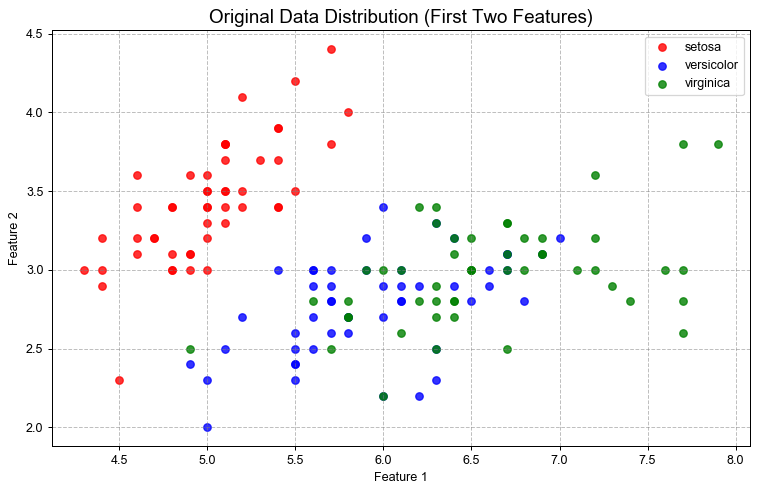

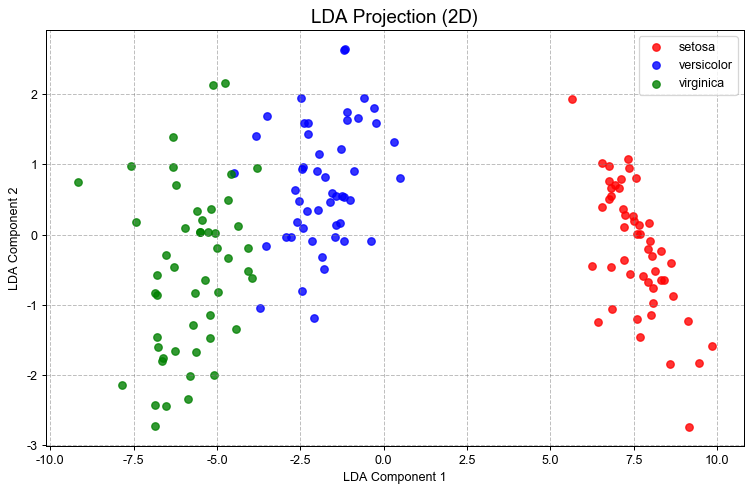

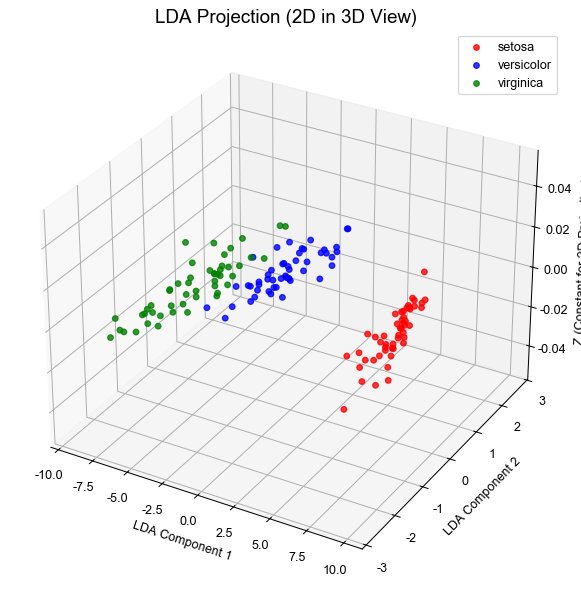

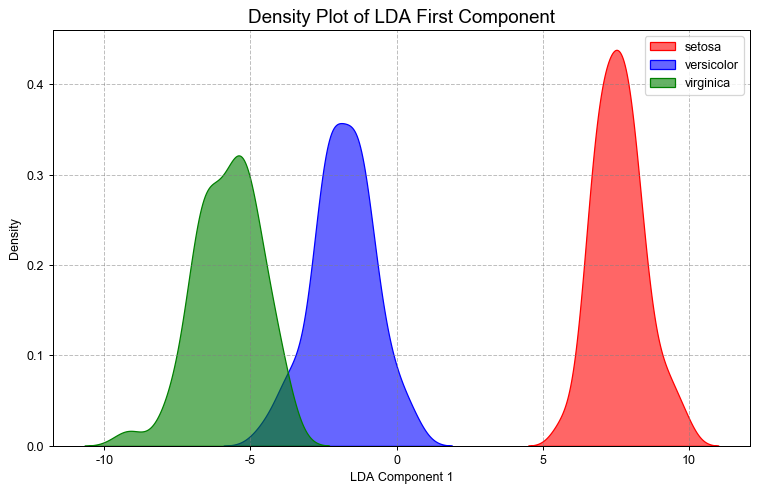

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# 加载数据集
data = load_iris()
X = data.data  # 特征数据 (4维)
y = data.target  # 类别标签 (3类)
target_names = data.target_names

# 1. 原始数据的分布图（前两维特征）
plt.figure(figsize=(10, 6))
for target, color in zip(range(len(target_names)), ['red', 'blue', 'green']):
    plt.scatter(X[y == target, 0], X[y == target, 1], alpha=0.8, color=color, label=target_names[target])
plt.title("Original Data Distribution (First Two Features)", fontsize=15)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.show()

# 2. LDA 降维到 2D 的散点图
lda = LDA(n_components=2)
X_lda_2d = lda.fit_transform(X, y)

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
for i, color in zip(range(len(target_names)), colors):
    plt.scatter(X_lda_2d[y == i, 0], X_lda_2d[y == i, 1], alpha=0.8, color=color, label=target_names[i])
plt.title("LDA Projection (2D)", fontsize=15)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.legend()
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.show()

# 3. LDA 降维到 2D 的立体图（由于 LDA 最大只能降到 2D，因此这里也使用 2D）
# 立体图效果不是必须的，但我们将用一种"3D"样式展示
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for i, color in zip(range(len(target_names)), colors):
    ax.scatter(X_lda_2d[y == i, 0], X_lda_2d[y == i, 1], np.zeros_like(X_lda_2d[y == i, 0]), alpha=0.8, color=color, label=target_names[i])
ax.set_title("LDA Projection (2D in 3D View)", fontsize=15)
ax.set_xlabel("LDA Component 1")
ax.set_ylabel("LDA Component 2")
ax.set_zlabel("Z (Constant for 2D Projection)")
ax.legend()
plt.show()

# 4. 每类别的密度分布曲线 (LDA 第一个投影方向)
plt.figure(figsize=(10, 6))
sns.kdeplot(X_lda_2d[y == 0, 0], color='red', fill=True, label=target_names[0], alpha=0.6)
sns.kdeplot(X_lda_2d[y == 1, 0], color='blue', fill=True, label=target_names[1], alpha=0.6)
sns.kdeplot(X_lda_2d[y == 2, 0], color='green', fill=True, label=target_names[2], alpha=0.6)
plt.title("Density Plot of LDA First Component", fontsize=15)
plt.xlabel("LDA Component 1")
plt.ylabel("Density")
plt.legend()
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.show()

1. **数据加载**：使用 Iris 数据集，每个样本有 4 个特征，目标是将其降维到 2D 和 3D。
2. **原始分布**：绘制前两个特征的散点图，展示原始数据分布。
3. **LDA 降维**：使用 `sklearn.discriminant_analysis.LDA`，将 4D 数据投影到 2D 和 3D。

原始数据的散点分布：

![原文参考图，当前结果见代码输出](attachments/img_024.png)

LDA 2D 投影后的类别分布图：

![原文参考图，当前结果见代码输出](attachments/img_025.png)

LDA 3D 投影后炫酷的立体类别分布：

![原文参考图，当前结果见代码输出](attachments/img_026.png)

类别密度曲线，展示类别间在主成分上的分离程度：

![原文参考图，当前结果见代码输出](attachments/img_027.png)

## 总结

线性判别分析的重要性在于它能把复杂的数据投影到更简单的空间里，同时尽量让不同类别分得更开，这样既能降维又能保留对分类最有用的信息，说白了就是让数据更清晰、更容易做分类。